# Import thư viện

In [ ]:
!pip install pyfolio
!pip install -U matplotlib
!pip install backtrader
!pip install -U seaborn
!pip install quantstats
!pip install scikeras
!pip install tensorflow
!pip install -U squarify
!pip install vnstock==0.2.9.0
!pip install pandas==2.0.3
!pip install numpy==1.24.3

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import backtrader as bt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import LSTM, Flatten, Dense, Masking
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasRegressor
from vnstock import *
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

# Lọc 50 cổ phiếu có return cao nhất theo chiến thuật SMA
## Tải giá đóng cửa và thực hiện chiến thuật Trading SMA

In [ ]:
# Tải giá đóng cửa và thực hiện chiến thuật Trading SMA

list=listing_companies()
list=list[(list['organTypeCode']=='DN')&(list['comGroupCode']=='HOSE')]
mcp=list.ticker.to_list()

import backtrader as bt

class Basic_MACrossStrategy(bt.Strategy):
    params = dict(ma_short_period=20, ma_long_period=50)

    def __init__(self):
        # Define the short-term (20-period) moving average
        self.ma_short = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_short_period,
                                                          plotname='MA 20')

        # Define the long-term (50-period) moving average
        self.ma_long = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_long_period,
                                                         plotname='MA 50')

        # Define the crossover signal (1 for upward cross, -1 for downward cross)
        self.crossover = bt.indicators.CrossOver(self.ma_short, self.ma_long)

    def next(self):
        # Buy when the short MA crosses above the long MA
        if self.crossover > 0 and not self.position:
            self.buy(size=None)
            print(f'BUY CREATE, {self.data.datetime.date(0)}, Price: {self.data.close[0]:.2f}')

        # Sell when the short MA crosses below the long MA
        elif self.crossover < 0 and self.position:
            self.sell(size=None)
            print(f'SELL CREATE, {self.data.datetime.date(0)}, Price: {self.data.close[0]:.2f}')


R_ma_check=[]
ticker_ma_check=[]
for i in mcp:
    try:
        DT=stock_historical_data(i, '2018-01-01', '2023-12-31')
        DT['time'] = pd.to_datetime(DT['time'])
        DT = DT.set_index('time')
        #TẠO DỮ LIỆU
        if len(DT)<1499:
            continue
        DT[(DT.index >= '2018-01-01') & (DT.index <= '2022-12-31')]
        if len(DT)<1250:
            continue
        data=bt.feeds.PandasData(dataname=DT)#DT LÀ DỮ LIÊU CỔ PHIẾU ĐÃ ĐƯỢC LẤY Ở TRÊN

        #thực thi chiến thuật
        cerebro=bt.Cerebro() #tạo cerebro

        cerebro.addstrategy(Basic_MACrossStrategy) #truyền chiến thuật


        cerebro.adddata(data) #truyền dữ liệu


        cerebro.broker.setcash(1000000000) #số tiền đầu tư
        cerebro.broker.setcommission(commission=0.0015) #số tiền hoa hồng/giao dịch
        cerebro.addsizer(bt.sizers.AllInSizerInt,percents = 95)#số cổ phiếu mua mỗi giao dịch


        print(i)
        before=cerebro.broker.getvalue()
        print('Số tiền trước khi thực hiện chiến thuật: %.2f' % before)
        cerebro.run() #thực thi chiến thuật
        after=cerebro.broker.getvalue()
        print('Số tiền sau khi thực hiện chiến thuật: %.2f' % after)
        r=(after-before)/before
        ticker_ma_check.append(i)
        R_ma_check.append(r)
    except Exception:
        continue
return_ma_check=pd.DataFrame({'Ticker':ticker_ma_check,'Return':R_ma_check})

return_ma_check=return_ma_check.sort_values('Return',ascending=False).head(50)

mcp=return_ma_check.Ticker.to_list()

list_allo=pd.DataFrame({'Asset':mcp})

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
SELL CREATE, 2019-03-29, Price: 14490.00
BUY CREATE, 2019-07-22, Price: 12280.00
SELL CREATE, 2019-07-29, Price: 11730.00
BUY CREATE, 2019-09-06, Price: 12570.00
SELL CREATE, 2019-11-01, Price: 12690.00
BUY CREATE, 2020-05-19, Price: 9070.00
SELL CREATE, 2020-07-21, Price: 8370.00
BUY CREATE, 2020-09-18, Price: 8740.00
SELL CREATE, 2021-05-11, Price: 19860.00
BUY CREATE, 2021-05-28, Price: 22340.00
SELL CREATE, 2021-07-01, Price: 19620.00
BUY CREATE, 2021-08-26, Price: 17410.00
SELL CREATE, 2021-09-16, Price: 17710.00
BUY CREATE, 2021-09-27, Price: 17990.00
SELL CREATE, 2021-09-29, Price: 18040.00
BUY CREATE, 2021-10-13, Price: 20360.00
SELL CREATE, 2022-02-14, Price: 33140.00
BUY CREATE, 2022-02-22, Price: 36740.00
SELL CREATE, 2022-04-22, Price: 32810.00
BUY CREATE, 2022-08-03, Price: 25570.00
SELL CREATE, 2022-09-26, Price: 21870.00
BUY CREATE, 2022-12-19, Price: 13350.00
SELL CREATE, 2023-02-10, Price: 10980.00
BUY CREATE, 20

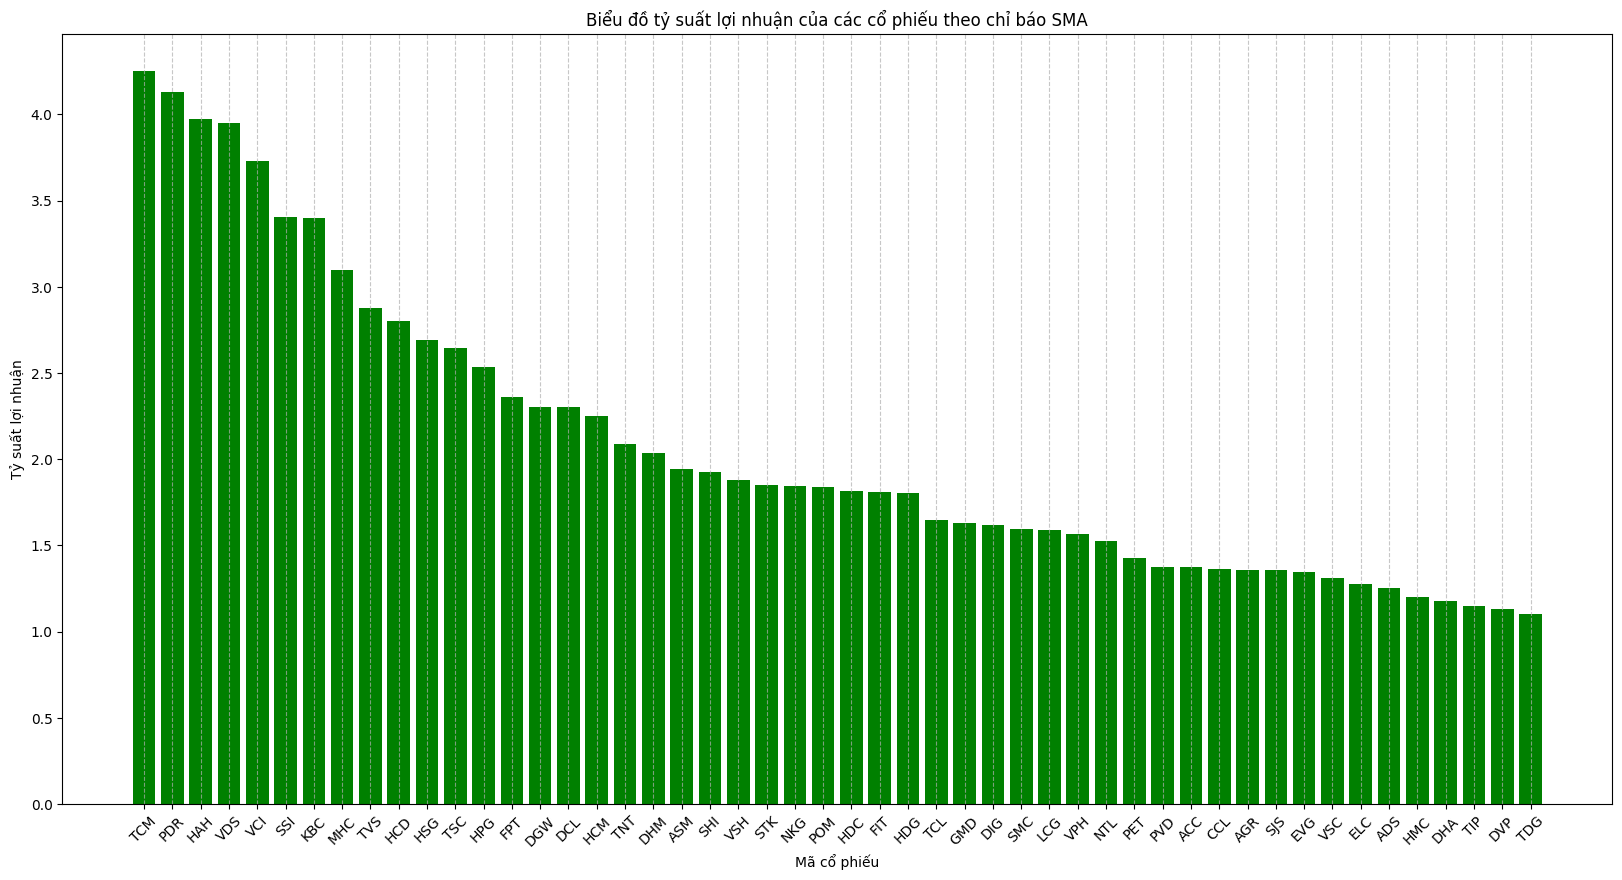

In [ ]:
plt.figure(figsize=(20, 10))
plt.bar(return_ma_check['Ticker'], return_ma_check['Return'],color='green')
plt.xlabel('Mã cổ phiếu')
plt.ylabel('Tỷ suất lợi nhuận')
plt.title('Biểu đồ tỷ suất lợi nhuận của các cổ phiếu theo chỉ báo SMA')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
mcp=list_allo.Asset.to_list()

# Khai báo chiến thuật SMA

### Ý tưởng chính là chia dữ liệu theo từng quý và chỉ tính lợi nhuận trong những khoảng thời gian mà có nắm giữ cổ phiếu (tức là chỉ khi đã mua cổ phiếu và trước khi bán).

In [ ]:
class MACrossStrategy(bt.Strategy):
    params = dict(ma_short_period=20, ma_long_period=50)

    def __init__(self):
        self.ma_short = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_short_period,
                                                          plotname='MA 20')
        self.ma_long = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_long_period,
                                                         plotname='MA 50')
        self.crossover = bt.indicators.CrossOver(self.ma_short, self.ma_long)
        self.last_order = None
        self.buy_price = None
        self.holding = False  # Trạng thái có nắm giữ cổ phiếu không
        self.current_quarter = None
        self.quarterly_returns = {}  # Lưu return theo từng quý

    def next(self):
        current_month = self.data.datetime.date(0).month
        current_year = self.data.datetime.date(0).year
        current_quarter = (current_year, (current_month - 1) // 3 + 1)  # Chia tháng theo quý

        if current_quarter not in self.quarterly_returns:
            self.quarterly_returns[current_quarter] = 0

        # Mua cổ phiếu khi có tín hiệu
        if self.crossover > 0 and not self.position:
            self.buy_price = self.data.close[0]
            self.buy(size=None)
            self.holding = True
            self.current_quarter = current_quarter
            print(f'BUY CREATE: {self.data.datetime.date(0)} - Buy price: {self.data.close[0]:.2f}')

        # Bán cổ phiếu khi có tín hiệu
        elif self.crossover < 0 and self.position:
            sell_price = self.data.close[0]
            self.sell(size=None)
            profit_pct = (sell_price - self.buy_price) / self.buy_price
            self.holding = False
            self.quarterly_returns[self.current_quarter] += profit_pct
            print(f'SELL CREATE: {self.data.datetime.date(0)} - Sell price: {self.data.close[0]:.2f}, Profit: {profit_pct:.2%}')

    def stop(self):
        if self.holding:
            sell_price = self.data.close[0]
            profit_pct = (sell_price - self.buy_price) / self.buy_price
            self.quarterly_returns[self.current_quarter] += profit_pct
            print(f'SELL ALL at the end: {self.data.datetime.date(0)} - Sell price: {self.data.close[0]:.2f}, Profit: {profit_pct:.2%}')

In [ ]:
# Khai báo biến lưu kết quả
quarterly_returns_MA = {}

for i in mcp:
    try:
        print(f"\nĐang xử lý mã: {i}")

        DT = stock_historical_data(i, '2018-01-01', '2023-12-31')
        DT['time'] = pd.to_datetime(DT['time'])
        DT = DT.reset_index()
        DT = DT.drop_duplicates(subset=['ticker', 'time'])
        DT = DT.set_index('time')

        data = bt.feeds.PandasData(dataname=DT)

        cerebro = bt.Cerebro()
        cerebro.addstrategy(MACrossStrategy)
        cerebro.adddata(data, name=i)
        cerebro.broker.setcash(1000000000)
        cerebro.broker.setcommission(commission=0.0015)
        cerebro.addsizer(bt.sizers.AllInSizerInt, percents=95)

        before = cerebro.broker.getvalue()
        print(f'Số tiền ban đầu: {before:.2f}')

        # Chạy chiến lược
        strategy_instances = cerebro.run()

        after = cerebro.broker.getvalue()
        print(f'Số tiền sau khi thực hiện chiến lược: {after:.2f}')

        # Tính tỷ lệ lợi nhuận
        r = (after - before) / before
        print(f'Lợi nhuận từ mã {i}: {r:.2%}')

        # Lưu lợi nhuận theo quý cho mã này
        quarterly_returns_MA[i] = strategy_instances[0].quarterly_returns

    except Exception as e:
        print(f"Error processing {i}: {e}")
        continue

# Chuyển kết quả quarterly_returns_MA thành DataFrame
quarterly_returns_df = pd.DataFrame.from_dict(quarterly_returns_MA, orient='index').T


Đang xử lý mã: TCM
Số tiền ban đầu: 1000000000.00
BUY CREATE: 2018-06-19 - Buy price: 9970.00
SELL CREATE: 2018-07-09 - Sell price: 8560.00, Profit: -14.14%
BUY CREATE: 2018-08-15 - Buy price: 9780.00
SELL CREATE: 2018-11-01 - Sell price: 11780.00, Profit: 20.45%
BUY CREATE: 2019-01-30 - Buy price: 13230.00
SELL CREATE: 2019-04-18 - Sell price: 14930.00, Profit: 12.85%
BUY CREATE: 2019-06-04 - Buy price: 14540.00
SELL CREATE: 2019-06-07 - Sell price: 14630.00, Profit: 0.62%
BUY CREATE: 2020-01-17 - Buy price: 11350.00
SELL CREATE: 2020-02-26 - Sell price: 10170.00, Profit: -10.40%
BUY CREATE: 2020-05-07 - Buy price: 8550.00
SELL CREATE: 2021-05-26 - Sell price: 61390.00, Profit: 618.01%
BUY CREATE: 2021-07-08 - Buy price: 61320.00
SELL CREATE: 2021-07-23 - Sell price: 54430.00, Profit: -11.24%
BUY CREATE: 2021-10-28 - Buy price: 52550.00
SELL CREATE: 2021-12-20 - Sell price: 49660.00, Profit: -5.50%
BUY CREATE: 2022-02-28 - Buy price: 46700.00
SELL CREATE: 2022-05-09 - Sell price: 436

In [ ]:
# Tạo tệp train từ năm 2018 đến 2022
train_data = quarterly_returns_df.loc[quarterly_returns_df.index.get_level_values(0) <= 2022]
# Tạo tệp test cho năm 2023
test_data = quarterly_returns_df.loc[quarterly_returns_df.index.get_level_values(0) == 2023]
# Reset index để đưa 'year' và 'quarter' về thành cột
train_data = train_data.reset_index()
test_data = test_data.reset_index()

In [ ]:
# Xóa cột 'year' và 'quarter' sau khi reset index
train_data = train_data.drop(columns=['level_0','level_1'])
test_data = test_data.drop(columns=['level_0','level_1'])

In [ ]:
train_data

,TCM,PDR,HAH,VDS,VCI,SSI,KBC,MHC,TVS,HCD,...,SJS,EVG,VSC,ELC,ADS,HMC,DHA,TIP,DVP,TDG
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.040223,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.141424,0.000000,-0.118162,0.000000,0.000000,0.000000,-0.072692,-0.117351,0.039400,0.276316,...,0.000000,-0.027507,-0.031128,-0.106136,-0.032023,0.000000,-0.033010,-0.132137,0.000000,-0.084571
2,0.204499,0.018764,-0.042697,0.036281,-0.179759,-0.075973,0.008178,0.000000,0.000000,0.000000,...,-0.058851,-0.091999,0.074822,-0.143617,0.000000,0.039024,0.046341,-0.028948,-0.054649,0.000000
3,0.000000,-0.083770,-0.102862,0.000000,0.000000,-0.076152,0.093148,0.000000,0.000000,-0.286874,...,0.089298,0.000000,-0.047952,0.000000,-0.090769,0.275430,0.000000,0.454437,-0.053077,-0.188277
4,0.128496,0.224380,0.018779,0.025126,-0.090467,-0.042914,0.000000,-0.078014,-0.054187,-0.047493,...,0.000000,-0.078431,-0.029787,0.000000,0.000000,0.000000,0.159404,0.000000,0.000000,-0.168874
5,0.006190,0.000000,-0.044444,-0.039506,0.000000,0.000000,0.066271,-0.043147,0.050167,0.000000,...,-0.125320,0.000000,0.000000,-0.044554,0.136042,0.000000,0.000000,0.000000,0.102153,0.000000
6,0.000000,0.000000,0.097872,-0.024752,0.046753,0.000000,0.000000,-0.043928,0.000000,-0.023166,...,0.000000,-0.042916,-0.018970,0.000000,0.000000,-0.053551,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.011246,0.000000,0.000000,-0.056497,-0.054224,0.006361,0.000000,0.044586,-0.220974,...,-0.106195,-0.036585,-0.073306,0.000000,0.000000,0.000000,-0.115727,0.000000,0.000000,0.000000
8,-0.103965,-0.027314,0.000000,-0.094059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.003632,0.000000,-0.104683,-0.088180,-0.101881,0.000000,-0.080605,-0.010126,0.012500
9,6.180117,0.047210,0.055263,0.000000,0.062724,0.202509,0.082164,1.310219,0.000000,0.066667,...,0.026316,0.424370,0.083578,0.000000,0.000000,0.034884,-0.063760,0.089716,-0.032485,0.000000


In [ ]:
test_data

,TCM,PDR,HAH,VDS,VCI,SSI,KBC,MHC,TVS,HCD,...,SJS,EVG,VSC,ELC,ADS,HMC,DHA,TIP,DVP,TDG
0,0.000000,0.000000,0.000000,-0.040521,0.00000,0.504481,0.000000,0.000000,-0.087741,0.000000,...,-0.060417,-0.032609,-0.026901,0.000000,0.134259,0.000000,0.000000,0.000000,0.000000,-0.008746
1,-0.060782,0.745064,0.133784,0.928763,0.00000,0.000000,0.329341,1.153846,0.395932,0.262324,...,-0.066667,0.978395,0.084049,0.000000,0.470417,0.023638,0.402316,0.118323,0.269451,0.413793
2,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.104149,0.000000,...,0.255507,-0.072702,0.000000,0.495438,0.000000,0.000000,0.000000,-0.013345,0.000000,0.000000
3,0.000000,-0.022913,0.041733,0.085633,0.05163,0.047872,0.020900,0.037528,0.060254,0.013158,...,0.084375,0.058052,0.040502,0.149394,-0.073563,-0.018555,0.007098,0.034619,0.150407,0.000000


## Chạy model

In [ ]:
# Lớp CustomModel với hàm sharpe_loss
class CustomModel:
    def __init__(self, data):
        self.data = data

    def sharpe_loss(self, _, y_pred):
        # Chia giá trị từng cột cho giá trị đầu tiên của cột đó
        data_normalized = tf.divide(self.data, self.data[0] + K.epsilon())
        # Tính giá trị danh mục đầu tư (portfolio)
        portfolio_values = tf.reduce_sum(tf.multiply(data_normalized, y_pred), axis=1)
        # Tránh chia cho 0 hoặc các giá trị bất thường
        portfolio_values = tf.where(tf.equal(portfolio_values, 0), K.epsilon(), portfolio_values)
        # Tính toán lợi nhuận danh mục đầu tư
        portfolio_returns = (portfolio_values[1:] - portfolio_values[:-1]) / (portfolio_values[:-1] + K.epsilon())
        # Tính Sharpe ratio
        sharpe = K.mean(portfolio_returns) / (K.std(portfolio_returns) + K.epsilon())
        return -sharpe

In [ ]:
X_train = train_data.values[np.newaxis, :, :]
X_test = test_data.values[np.newaxis, :, :]
y_train = np.zeros((1, len(train_data.columns)))
y_test = np.zeros((1, len(test_data.columns)))

In [ ]:
# Khởi tạo mô hình tùy chỉnh
data_tensor = tf.cast(tf.constant(train_data), float)
custom_model = CustomModel(data_tensor)

In [ ]:
# Tạo mô hình LSTM
model = Sequential([
    LSTM(512, input_shape=train_data.shape),
    Flatten(),
    Dense(train_data.shape[1], activation='softmax')
])

# Biên dịch mô hình
model.compile(
    optimizer= 'Adam',
    loss=custom_model.sharpe_loss
)

In [ ]:
model_LSTM = model.fit(X_train, y_train, epochs=100, shuffle=False)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.2357
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.2357
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2357
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.2357
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.2357
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.2357
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.2357
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.2357
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.2357
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.2357
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.2357
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.2357
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.2357
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.2357
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.2357
Epoch 16/

In [ ]:
optimal_weights = model.predict(X_train)
coeff_1 = optimal_weights[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


In [ ]:
results_LSTM = pd.DataFrame({'Asset':mcp,"Weight":coeff_1})

In [ ]:
results_LSTM

,Asset,Weight
0,TCM,0.016021
1,PDR,0.024538
2,HAH,0.031464
3,VDS,0.021913
4,VCI,0.020282
5,SSI,0.025178
6,KBC,0.012945
7,MHC,0.015081
8,TVS,0.016933
9,HCD,0.039943


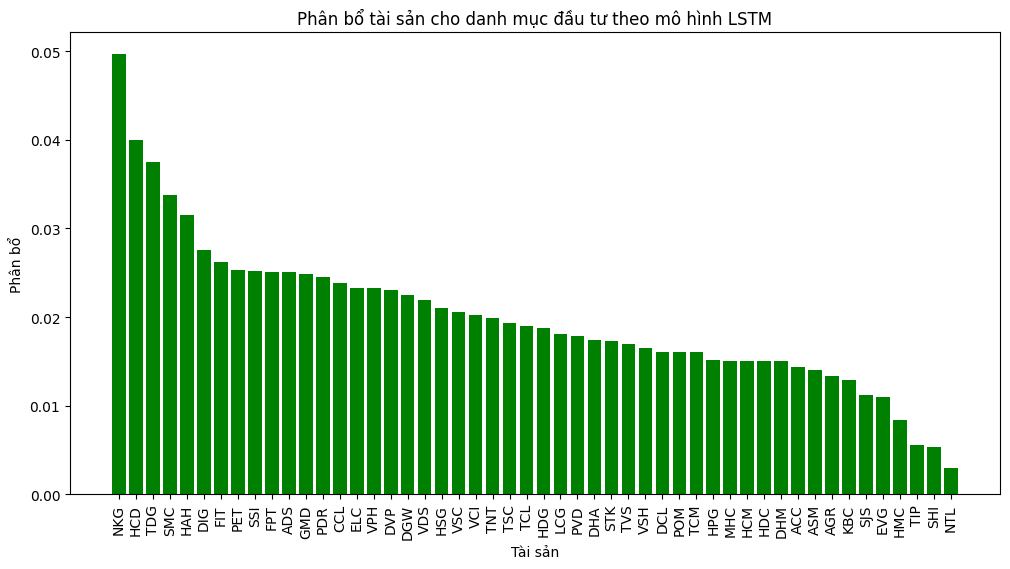

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(results_LSTM.sort_values('Weight',ascending=False).Asset,
        results_LSTM.sort_values('Weight',ascending=False).Weight, color='green')
plt.xlabel('Tài sản')
plt.ylabel('Phân bổ')
plt.title('Phân bổ tài sản cho danh mục đầu tư theo mô hình LSTM')
plt.xticks(rotation=90)
plt.show()

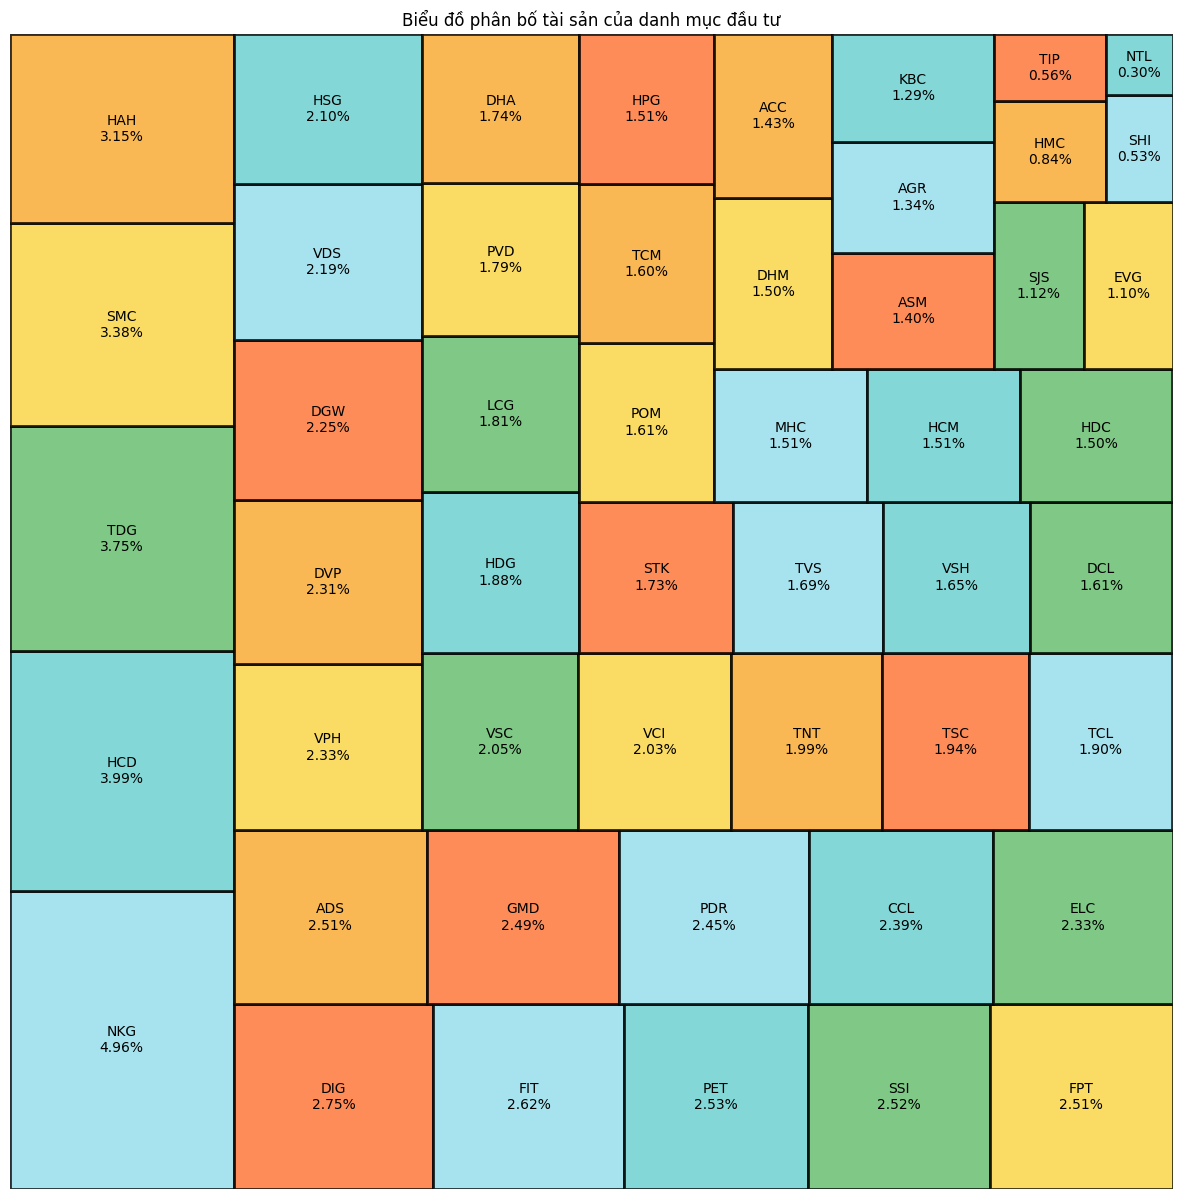

In [ ]:
square_plot_test = pd.DataFrame({
    'Cổ phiếu': results_LSTM.sort_values('Weight',ascending=False).Asset,
    'Tỷ trọng': results_LSTM.sort_values('Weight',ascending=False).Weight
})
square_plot_test.sort_values('Tỷ trọng',ascending=True)
# Tạo nhãn mới bao gồm cả tên cổ phiếu và khối lượng
square_plot_test['Nhãn'] = square_plot_test['Cổ phiếu'] + '\n' + square_plot_test['Tỷ trọng'].apply(lambda x: f"{x*100:.2f}").astype(str)+'%'

# Định nghĩa màu sắc cho các khối vuông
colors = ['#91DCEA', '#64CDCC', '#5FBB68', '#F9D23C', '#F9A729', '#FD6F30']

# Vẽ biểu đồ khối vuông
plt.figure(figsize=(15, 15))
squarify.plot(sizes=square_plot_test['Tỷ trọng'], label=square_plot_test['Nhãn'], color=colors, alpha=.8, edgecolor='black', linewidth=2, text_kwargs={'fontsize':10})
plt.axis('off')
plt.title('Biểu đồ phân bố tài sản của danh mục đầu tư')
plt.show()


# Tính toán E(r), Stddev và Sharpe ratio của danh mục và so sánh với allo 1 và allo 2

In [ ]:
import numpy as np

def port_char(weights_df, returns_df):
    Er=returns_df.mean().reset_index()
    Er.columns=['Asset','Er']
    weights_df=pd.merge(weights_df,Er,on='Asset',how='outer')
    # Tính E(r) của portfolio
    portfolio_er = np.dot(weights_df['Weight'], weights_df['Er'])

    # Tính ma trận hiệp phương sai
    cov_matrix = returns_df.cov()

    # Tính độ lệch chuẩn của portfolio
    portfolio_std_dev = np.sqrt(np.dot(weights_df['Weight'].T, np.dot(cov_matrix, weights_df['Weight'])))

    return portfolio_er, portfolio_std_dev


# Hàm tính toán tỷ lệ Sharpe của danh mục
def sharpe_port(weights_df, returns_df):
    # Tính E(r) và std_dev của portfolio
    portfolio_er, portfolio_std_dev = port_char(weights_df, returns_df)

    # Tính Sharpe Ratio
    sharpe_ratio = (portfolio_er -(0.016/(52*5)))/ portfolio_std_dev

    return sharpe_ratio


In [ ]:
results_LSTM

,Asset,Weight
0,TCM,0.016021
1,PDR,0.024538
2,HAH,0.031464
3,VDS,0.021913
4,VCI,0.020282
5,SSI,0.025178
6,KBC,0.012945
7,MHC,0.015081
8,TVS,0.016933
9,HCD,0.039943


In [ ]:
test_data

,TCM,PDR,HAH,VDS,VCI,SSI,KBC,MHC,TVS,HCD,...,SJS,EVG,VSC,ELC,ADS,HMC,DHA,TIP,DVP,TDG
0,0.000000,0.000000,0.000000,-0.040521,0.00000,0.504481,0.000000,0.000000,-0.087741,0.000000,...,-0.060417,-0.032609,-0.026901,0.000000,0.134259,0.000000,0.000000,0.000000,0.000000,-0.008746
1,-0.060782,0.745064,0.133784,0.928763,0.00000,0.000000,0.329341,1.153846,0.395932,0.262324,...,-0.066667,0.978395,0.084049,0.000000,0.470417,0.023638,0.402316,0.118323,0.269451,0.413793
2,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.104149,0.000000,...,0.255507,-0.072702,0.000000,0.495438,0.000000,0.000000,0.000000,-0.013345,0.000000,0.000000
3,0.000000,-0.022913,0.041733,0.085633,0.05163,0.047872,0.020900,0.037528,0.060254,0.013158,...,0.084375,0.058052,0.040502,0.149394,-0.073563,-0.018555,0.007098,0.034619,0.150407,0.000000


In [ ]:
Er,std_dev=port_char(results_LSTM,test_data)

In [ ]:
sharpe_LSTM=sharpe_port(results_LSTM,test_data)

In [ ]:
Allo_1=results_LSTM[['Asset']]

In [ ]:
Allo_1['Weight']=1/50

In [ ]:
Allo_2=train_data.sum().sort_values(ascending=False).reset_index()
Allo_2.columns=['Asset','Er']

In [ ]:
Allo_2['Weight']=[0.8/(0.2*len(mcp))] * int(0.2*len(mcp)) + [0.2/(0.8*len(mcp))] * int(0.8*len(mcp))

In [ ]:
Allo_2=Allo_2[['Asset','Weight']]

In [ ]:
sharpe_LSTM

0.6373475693967986

In [ ]:
sharpe_port(Allo_1,test_data)

0.6321701332191654

In [ ]:
sharpe_port(Allo_2,test_data)

0.28628663872369253

In [ ]:
Er,std_dev=port_char(results_LSTM,test_data)
Er_1,std_dev_1=port_char(Allo_1,test_data)
Er_2,std_dev_2=port_char(Allo_2,test_data)
table=pd.DataFrame({'Er':[Er,Er_1,Er_2],'Std_dev':[std_dev,std_dev_1,std_dev_2],
                    'Sharpe':[sharpe_port(results_LSTM,test_data),sharpe_port(Allo_1,test_data),sharpe_port(Allo_2,test_data)]})
table=table.T
table=table.rename(columns={0:'LSTM',1:'Allo_1',2:'Allo_2'})

In [ ]:
table

,LSTM,Allo_1,Allo_2
Er,0.077428,0.072544,0.048084
Std_dev,0.121389,0.114656,0.167744
Sharpe,0.637348,0.632170,0.286287


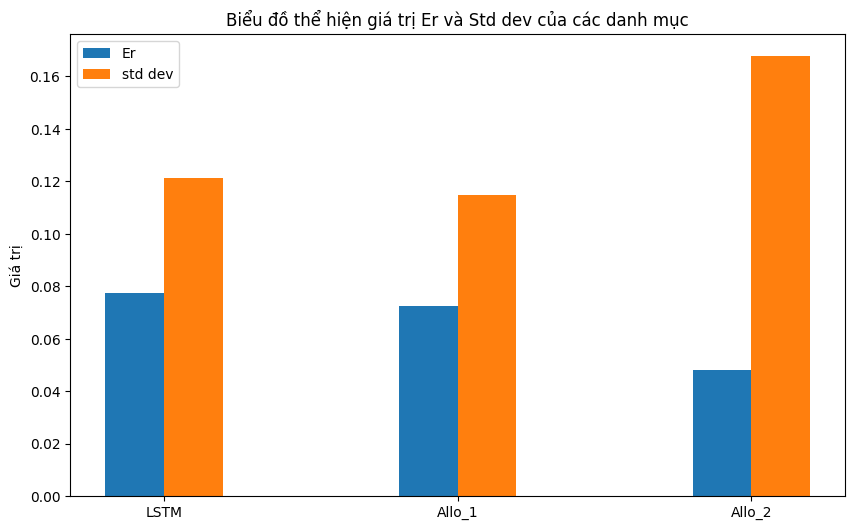

In [ ]:
plt.figure(figsize=(10, 6))
categories=table.columns.values
er_values=table.loc['Er'].values
std_dev_values=table.loc['Std_dev'].values

width = 0.2
x_corr = np.arange(len(categories))
plt.bar(x_corr,er_values,width,label='Er')
plt.bar((x_corr+width),std_dev_values,width,label='std dev')

plt.ylabel('Giá trị')
plt.title('Biểu đồ thể hiện giá trị Er và Std dev của các danh mục')
plt.xticks((x_corr+width/2),categories)
plt.legend()

plt.show()

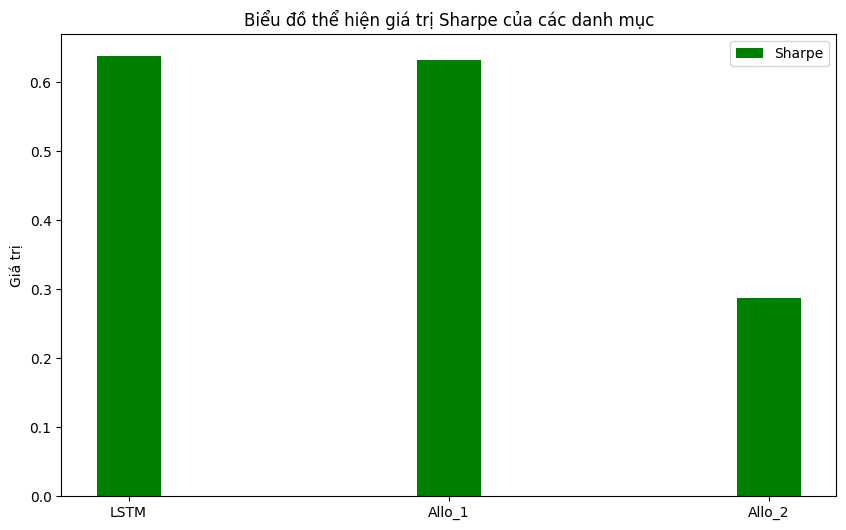

In [ ]:
plt.figure(figsize=(10, 6))

sharpe_values=table.loc['Sharpe'].values

x_corr = np.arange(len(categories))
plt.bar(x_corr,sharpe_values,width,label='Sharpe',color='green')


plt.ylabel('Giá trị')
plt.title('Biểu đồ thể hiện giá trị Sharpe của các danh mục')
plt.xticks((x_corr),categories)
plt.legend()

plt.show()